MACHINE LEARNING ASSIGNMENT- Ames housing predicition By Team 3
Ana lucia, Giana Kahil, Antonio Confuorti, Mark Kangun, Alessandra Mari London, Karim Tabet, Bhoomika Samantha Rasquinha

In [2]:
#Imports libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [3]:
# Load Train Data
train_df = pd.read_csv('Ames_train.csv')

In [4]:
# Filter relevant columns
train_df = train_df[['Gr Liv Area',
                     'Garage Area',
                     'Year Built',
                     'Garage Finish',
                     'SalePrice']]

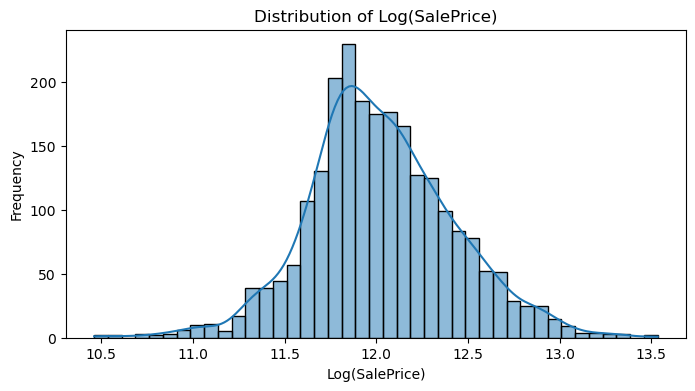

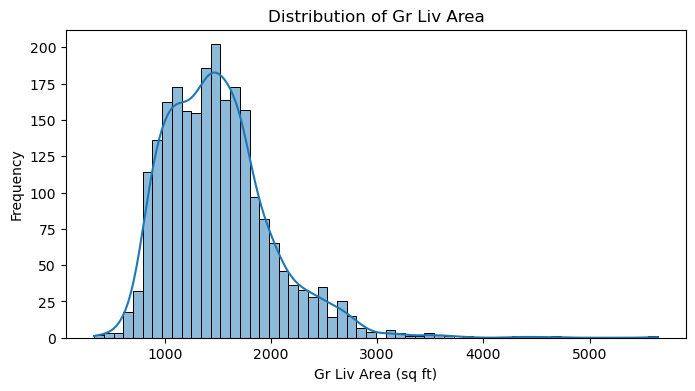

In [5]:
# Univariate EDA
#distribution of log(sale price)
plt.figure(figsize=(8, 4))
sns.histplot(np.log(train_df['SalePrice']), kde=True)
plt.title('Distribution of Log(SalePrice)')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frequency')
plt.show()

#distribution of gir
plt.figure(figsize=(8, 4))
sns.histplot(train_df['Gr Liv Area'], kde=True)
plt.title('Distribution of Gr Liv Area')
plt.xlabel('Gr Liv Area (sq ft)')
plt.ylabel('Frequency')
plt.show()

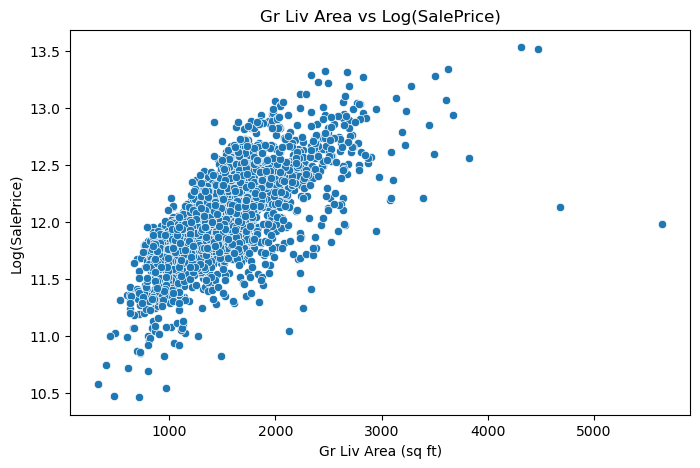

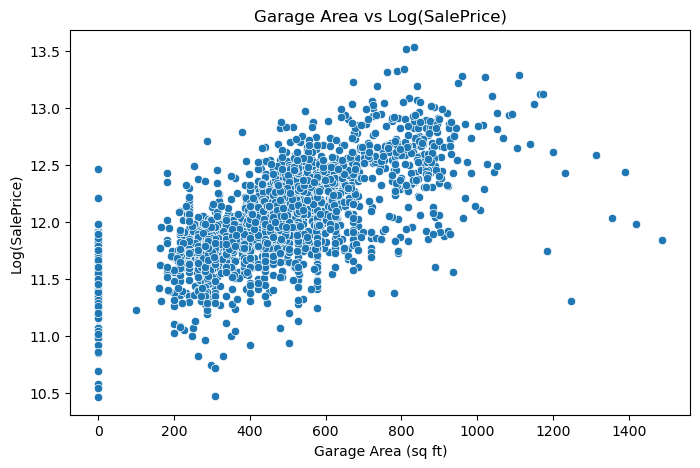

In [6]:
# Bivariate EDA
#1
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Gr Liv Area', y=np.log(train_df['SalePrice']), data=train_df)
plt.title('Gr Liv Area vs Log(SalePrice)')
plt.xlabel('Gr Liv Area (sq ft)')
plt.ylabel('Log(SalePrice)')
plt.show()

#2
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Garage Area', y=np.log(train_df['SalePrice']), data=train_df)
plt.title('Garage Area vs Log(SalePrice)')
plt.xlabel('Garage Area (sq ft)')
plt.ylabel('Log(SalePrice)')
plt.show()

In [7]:
#OHE
ohe = OneHotEncoder(categories='auto', handle_unknown='ignore')
categorical_features = ['Garage Finish']
feature_arr = ohe.fit_transform(train_df[categorical_features]).toarray()
features = pd.DataFrame(feature_arr, columns=ohe.get_feature_names_out())
train_df = pd.concat([train_df, features], axis=1).drop(columns=categorical_features, axis=1)

In [8]:
#Spliting features and target
X = train_df.drop(columns=['SalePrice']).fillna(0)
y = train_df[['SalePrice']]

In [9]:
#Feature Engineering
X['Garage_area_ratio'] = X['Garage Area'] / X['Gr Liv Area']
X['Total_area'] = X['Garage Area'] + X['Gr Liv Area']
for column in ['Gr Liv Area', 'Garage Area', 'Year Built', 'Garage_area_ratio', 'Total_area']:
    X[column + '_log'] = np.log(X[column] + 0.0001)

In [10]:
#more feature engineering
X['LuxuryScore'] = (X['Gr Liv Area'] > 2500).astype(int) + (X['Garage Area'] > 600).astype(int)
X['GarageEfficiency'] = X['Garage Area'] / (X['Gr Liv Area'] + 1)
X['AgeCat'] = pd.cut(2025 - X['Year Built'], bins=[0, 10, 40, 1000], labels=['New', 'Modern', 'Old'])
X = pd.concat([X, pd.get_dummies(X['AgeCat'], prefix='AgeCat')], axis=1)
X.drop('AgeCat', axis=1, inplace=True)
X['IsOverbuilt'] = (X['Garage Area'] > X['Gr Liv Area'] * 0.8).astype(int)
X['Garage_YearBuilt'] = X['Garage Area'] * X['Year Built']

In [11]:
#loading and prepping test date
test_df = pd.read_csv("Ames_test.csv")
test_df = test_df[['Gr Liv Area', 'Garage Area', 'Year Built', 'Garage Finish', 'SalePrice']]

In [12]:
# Apply OHE
feature_arr = ohe.transform(test_df[categorical_features]).toarray()
features = pd.DataFrame(feature_arr, columns=ohe.get_feature_names_out())
test_df = pd.concat([test_df, features], axis=1).drop(columns=categorical_features, axis=1)

In [13]:
# Create test features and target
X_test = test_df.drop(columns=['SalePrice']).fillna(0)

In [14]:
#test for feature eng
X_test['Garage_area_ratio'] = X_test['Garage Area'] / X_test['Gr Liv Area']
X_test['Total_area'] = X_test['Garage Area'] + X_test['Gr Liv Area']
for column in ['Gr Liv Area', 'Garage Area', 'Year Built', 'Garage_area_ratio', 'Total_area']:
    X_test[column + '_log'] = np.log(X_test[column] + 0.0001)

In [15]:
#test for more feature engineering
X_test['LuxuryScore'] = (X_test['Gr Liv Area'] > 2500).astype(int) + (X_test['Garage Area'] > 600).astype(int)
X_test['GarageEfficiency'] = X_test['Garage Area'] / (X_test['Gr Liv Area'] + 1)
X_test['AgeCat'] = pd.cut(2025 - X_test['Year Built'], bins=[0, 10, 40, 1000], labels=['New', 'Modern', 'Old'])
X_test = pd.concat([X_test, pd.get_dummies(X_test['AgeCat'], prefix='AgeCat')], axis=1)
X_test.drop('AgeCat', axis=1, inplace=True)

In [16]:
# creating AgeCat dummies with training data for binned conversion of house age
for col in ['AgeCat_New', 'AgeCat_Modern', 'AgeCat_Old']:
    if col not in X_test.columns:
        X_test[col] = 0

X_test['IsOverbuilt'] = (X_test['Garage Area'] > X_test['Gr Liv Area'] * 0.8).astype(int)
X_test['Garage_YearBuilt'] = X_test['Garage Area'] * X_test['Year Built']

In [17]:
# Test target
y_test = test_df[['SalePrice']]

In [18]:
#Train/Validation/Test Split
from sklearn.model_selection import train_test_split

# First split: 80% train+val, 20% test
X_trainval, X_test_final, y_trainval, y_test_final = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: 75% of trainval = 60% of total data for training, 25% = 20% for validation
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42)

# Check sizes
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Final Test size:", X_test_final.shape)

Train size: (1406, 21)
Validation size: (469, 21)
Final Test size: (469, 21)


In [19]:
#algo-1 RF
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    random_state=42,
    n_estimators=100,
    max_depth=10,
    max_features=0.7,
    max_samples=0.8
)

rf.fit(X_train, np.ravel(y_train))
val_pred_rf = rf.predict(X_val)

# Evaluate using Log-RMSE
log_rmse_rf = mean_squared_error(np.log(y_val), np.log(val_pred_rf), squared=False)
print("Validation Log-RMSE (Random Forest):", log_rmse_rf)


Validation Log-RMSE (Random Forest): 0.1767145151354382


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


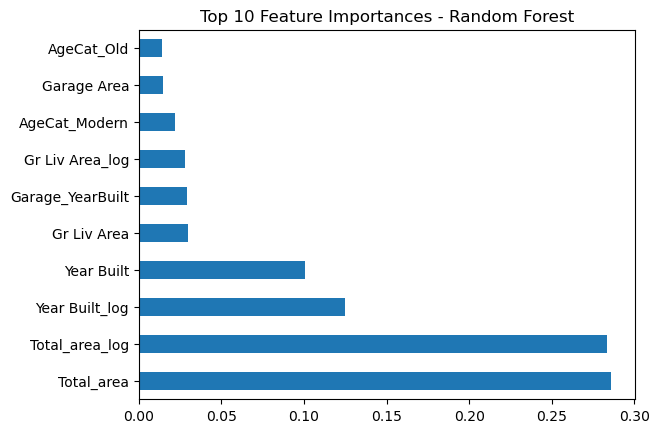

In [20]:
#for showing top features algo -1
import pandas as pd
import matplotlib.pyplot as plt

rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
rf_importances.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

In [21]:
#algo-2 GB
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.7,
    max_features=0.7,
    validation_fraction=0.2,
    n_iter_no_change=20
)

gb.fit(X_train, np.ravel(y_train))
val_pred_gb = gb.predict(X_val)

# Evaluate with Log-RMSE
log_rmse_gb = mean_squared_error(np.log(y_val), np.log(val_pred_gb), squared=False)
print("Validation Log-RMSE (Gradient Boosting):", log_rmse_gb)

Validation Log-RMSE (Gradient Boosting): 0.17445282478190652


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


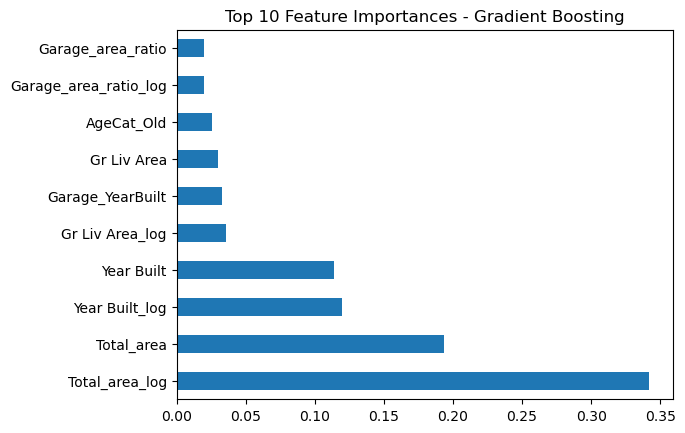

In [22]:
#for showing top features algo -2
gb_importances = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
gb_importances.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances - Gradient Boosting")
plt.show()

In [23]:
# Retraining on combined train+val set
best_model = GradientBoostingRegressor(
    random_state=42,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.7,
    max_features=0.7,
    validation_fraction=0.2,
    n_iter_no_change=20
)

best_model.fit(X_trainval, np.ravel(y_trainval))

# Predict on held-out test set
test_pred = best_model.predict(X_test_final)

# Evaluate with Log-RMSE
final_log_rmse = mean_squared_error(np.log(y_test_final), np.log(test_pred), squared=False)
print("Test Log-RMSE (Final Gradient Boosting Model):", final_log_rmse)


Test Log-RMSE (Final Gradient Boosting Model): 0.1931380701437221


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
